In [1]:
import numpy as np
import ultraplot as uplt
import xarray as xr
import cartopy.crs as ccrs
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape
from rasterio.features import shapes
from affine import Affine
from rasterio.features import rasterize
import xarray as xr
import cartopy.feature as cfeature
from numpy import ma 
from scipy.interpolate import interp1d
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerLine2D

import rioxarray


uplt.rc.style='seaborn-v0_8-paper'
uplt.rc.update({'tick.len': 2.0, 'tick.dir': 'in', 'font.largesize': 12, 'font.smallsize': 10})

In [8]:
# Function to retrieve spatial R² results for a given model type across multiple seeds
def get_r2_spatial(seeds, model_type):
    # Determine base directory path based on model type
    if model_type == "c1d":
        fold = "/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c1d-2/"
    elif model_type == "c3d":
        fold = "/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/"
    elif model_type == "kc3d":
        fold = "/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/"
    
    reslist = []
    # Process each seed's results
    for k in seeds:
        folder_path = fold + str(k)
        f = folder_path + "/"
        # Read spatial R² results from CSV file
        r2_df = pd.read_csv(f + "r2_spatial.csv")
        # Extract R² values column
        reslist.append(r2_df["r2"])
        reslist = reslist
    
    # Combine results from all seeds into single DataFrame
    res_df = pd.concat(reslist, axis=1)
    # Add latitude and longitude coordinates from original data
    res_df["lat"] = r2_df["lat"]
    res_df["lon"] = r2_df["lon"]
    # Calculate mean R² across all seed runs
    res_df["mean"] = np.mean(res_df.iloc[:, :len(seeds)], axis=1)
    return res_df

In [10]:
# Define seed lists for ESA-ERA model configurations
seeds_esa_era_c1d = [52, 57, 58, 59]      # Seeds for 1D convolutional model
seeds_esa_era_kc3d = [541, 540, 548]      # Seeds for kernel-based 3D convolutional model (note: 540 commented)
seeds_esa_era_c3d = [513, 512, 511]       # Seeds for 3D convolutional model (note: 511 commented)

# Retrieve spatial R² results for ESA-ERA 1D convolutional model
c1d = get_r2_spatial(seeds=seeds_esa_era_c1d, model_type="c1d")

# Retrieve spatial R² results for ESA-ERA 3D convolutional model
c3d = get_r2_spatial(seeds=seeds_esa_era_c3d, model_type="c3d")

# Retrieve spatial R² results for ESA-ERA kernel-based 3D convolutional model
kc3d = get_r2_spatial(seeds=seeds_esa_era_kc3d, model_type="kc3d")

In [16]:
# Convert ESA-ERA 1D model spatial results to 2D format using pivot table
df_pivot_c1d = c1d.pivot_table(index='lat', columns='lon', values='mean')
# Create xarray DataArray for 1D model with proper coordinates and dimensions
da_c1d = xr.DataArray(df_pivot_c1d, dims=('lat', 'lon'), coords={'lat': df_pivot_c1d.index, 'lon': df_pivot_c1d.columns})

# Convert ESA-ERA 3D model spatial results to 2D format using pivot table
df_pivot_c3d = c3d.pivot_table(index='lat', columns='lon', values='mean')
# Create xarray DataArray for 3D model with proper coordinates and dimensions
da_c3d = xr.DataArray(df_pivot_c3d, dims=('lat', 'lon'), coords={'lat': df_pivot_c3d.index, 'lon': df_pivot_c3d.columns})

# Convert ESA-ERA kernel-based 3D model spatial results to 2D format using pivot table
df_pivot_kc3d = kc3d.pivot_table(index='lat', columns='lon', values='mean')
# Create xarray DataArray for kernel-based 3D model with proper coordinates and dimensions
da_kc3d = xr.DataArray(df_pivot_kc3d, dims=('lat', 'lon'), coords={'lat': df_pivot_kc3d.index, 'lon': df_pivot_kc3d.columns})

In [17]:
# Calculate difference in R² between kernel-based 3D model and 1D model
kc3d_c1d = da_kc3d - da_c1d

# Calculate difference in R² between standard 3D model and 1D model  
c3d_c1d = da_c3d - da_c1d

In [21]:
# Load latitude and longitude arrays for 737 locations
lats = np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lats_737.npy")
lons = np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lons_737.npy")

# Load percentage data for SoMo model results
perc_somo = np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/perc_esa.npy')

# Create DataFrame with percentage data and corresponding coordinates
df_pivot_perc_somo = pd.DataFrame({'perc_somo': perc_somo, 'lat': lats, 'lon': lons}).pivot_table(index='lat', columns='lon', values='perc_somo')

# Convert to xarray DataArray with proper coordinates and dimensions
da_perc_somo = xr.DataArray(df_pivot_perc_somo, dims=('lat', 'lon'), coords={'lat': df_pivot_perc_somo.index, 'lon': df_pivot_perc_somo.columns})

In [18]:
# Load Amazon shapefile for geographical region masking
amazon_shapefile = "/Net/Groups/BGI/work_3/ML4HES/sjiang/plot_exercise/downwind/amazonia_polygons.shp"
# Read Amazon shapefile into GeoDataFrame
amazon_vector = gpd.read_file(amazon_shapefile)
# Dissolve all polygons into a single multi-polygon geometry
amazon_vector = amazon_vector.dissolve()
# Extract the first (and only) geometry as Amazon border
amazon_border = amazon_vector.loc[[0]]

# Load general geography regions shapefile for background mapping
geography_shapefile = "/Net/Groups/BGI/work_3/ML4HES/sjiang/plot_exercise/downwind/ne_10m_geography_regions_polys.shp"
# Read geography regions shapefile into GeoDataFrame
geography_vector = gpd.read_file(geography_shapefile)

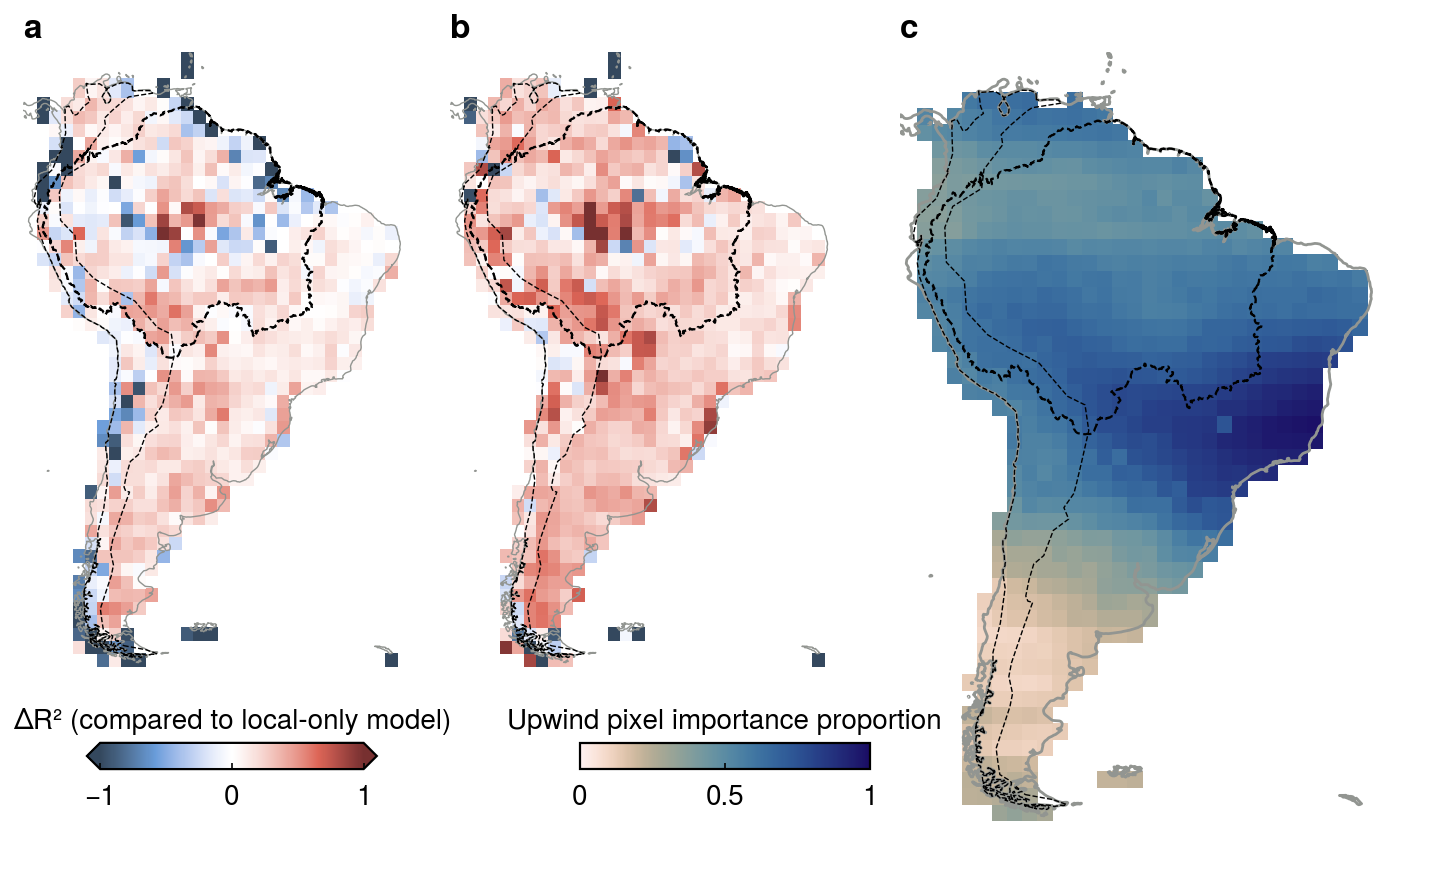

In [24]:
# Define geographical boundaries for the study area
lonlim = (-82, -32)
latlim = (-60, 15)
# Define map projection (using PlateCarree for simple lat/lon coordinates)
proj = ccrs.PlateCarree()

# Define complex subplot arrangement: 2 rows, 3 columns with empty cells
arrray = [
    [1, 2, 3],  # Row 1: three subplots
    [0, 0, 3]    # Row 2: third subplot spans both rows, others empty
]

# Create figure with specified width and layout settings
fig = uplt.figure(refwidth=2, share=False, span=False, tight=True)
# Create subplots with specified projection, arrangement, and aspect ratios
axs = fig.subplots(arrray, projection=proj, abc=True, width_ratios=[1, 1, 1.5], height_ratios=[4, 1])
# Format subplots with geographical boundaries and remove frame lines
axs.format(lonlim=lonlim, latlim=latlim, linewidth=0)

# First subplot: Difference between 3D model and 1D model (C3D - C1D)
ax = axs[0]
im = ax.pcolormesh(
    c3d_c1d.lon,           # Longitude coordinates
    c3d_c1d.lat,           # Latitude coordinates
    c3d_c1d.values,        # R² difference values
    cmap='negpos',         # Colormap for positive/negative differences
    discrete=False,        # Continuous color scale
    transform=ccrs.PlateCarree(),  # Coordinate transformation
    vmin=-1, vmax=1,       # Color scale limits
)

# Add Amazon border as dashed line
amazon_border.plot(ax=ax, linewidth=0.8, color='none', linestyle='--', zorder=50)
# Add Andes mountain range border
geography_vector[geography_vector['NAME']=='ANDES'].plot(ax=ax, linewidth=0.5, color='none', linestyle='--', zorder=50, ec='k')
# Add coastline feature
ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=0.5)

# Second subplot: Difference between kernel-based 3D model and 1D model (KC3D - C1D)
ax = axs[1]
im = ax.pcolormesh(
    kc3d_c1d.lon,          # Longitude coordinates
    kc3d_c1d.lat,          # Latitude coordinates
    kc3d_c1d.values,       # R² difference values
    cmap='negpos',         # Colormap for positive/negative differences
    discrete=False,        # Continuous color scale
    transform=ccrs.PlateCarree(),  # Coordinate transformation
    vmin=-1, vmax=1,       # Color scale limits
)

# Add Amazon border as dashed line
amazon_border.plot(ax=ax, linewidth=0.8, color='none', linestyle='--', zorder=50)
# Add Andes mountain range border
geography_vector[geography_vector['NAME']=='ANDES'].plot(ax=ax, linewidth=0.5, color='none', linestyle='--', zorder=50, ec='k')

# Add colorbar for R² difference plots at bottom left position
cax = fig.add_axes([0.06, 0.12, 0.2, 0.03], title='ΔR² (compared to local-only model)', titlesize=10)
fig.colorbar(
    im,                    # Image to create colorbar for
    cax=cax,               # Colorbar axis
    orientation='horizontal',  # Horizontal orientation
    extend='both',         # Extend arrows for out-of-range values
    ticks=[-1, 0, 1],      # Specific tick positions
)
# Add coastline feature to second subplot
ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=0.5)

# Third subplot: Upwind pixel importance proportion (spans both rows)
ax = axs[2]
im = ax.pcolormesh(
    da_perc_somo.lon,      # Longitude coordinates
    da_perc_somo.lat,      # Latitude coordinates
    da_perc_somo.values,   # Upwind importance proportion values
    cmap='lapaz_r',        # Reverse Lapaz colormap
    discrete=False,        # Continuous color scale
    transform=ccrs.PlateCarree(),  # Coordinate transformation
    vmin=0, vmax=1,        # Color scale limits (proportion 0-1)
)

# Add Amazon border as dashed line
amazon_border.plot(ax=ax, linewidth=0.8, color='none', linestyle='--', zorder=50)
# Add Andes mountain range border
geography_vector[geography_vector['NAME']=='ANDES'].plot(ax=ax, linewidth=0.5, color='none', linestyle='--', zorder=50, ec='k')
# Add coastline feature with thicker line
ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=1)

# Add colorbar for upwind importance proportion at bottom center position
cax = fig.add_axes([0.40, 0.12, 0.2, 0.03], title='Upwind pixel importance proportion', titlesize=10)
fig.colorbar(
    im,                    # Image to create colorbar for
    cax=cax,               # Colorbar axis
    orientation='horizontal',  # Horizontal orientation
    extend='neither',      # No extend arrows
    ticks=[0, 0.5, 1],     # Specific tick positions
)

Text(0.5, 0, 'Average variable contribution (%)')

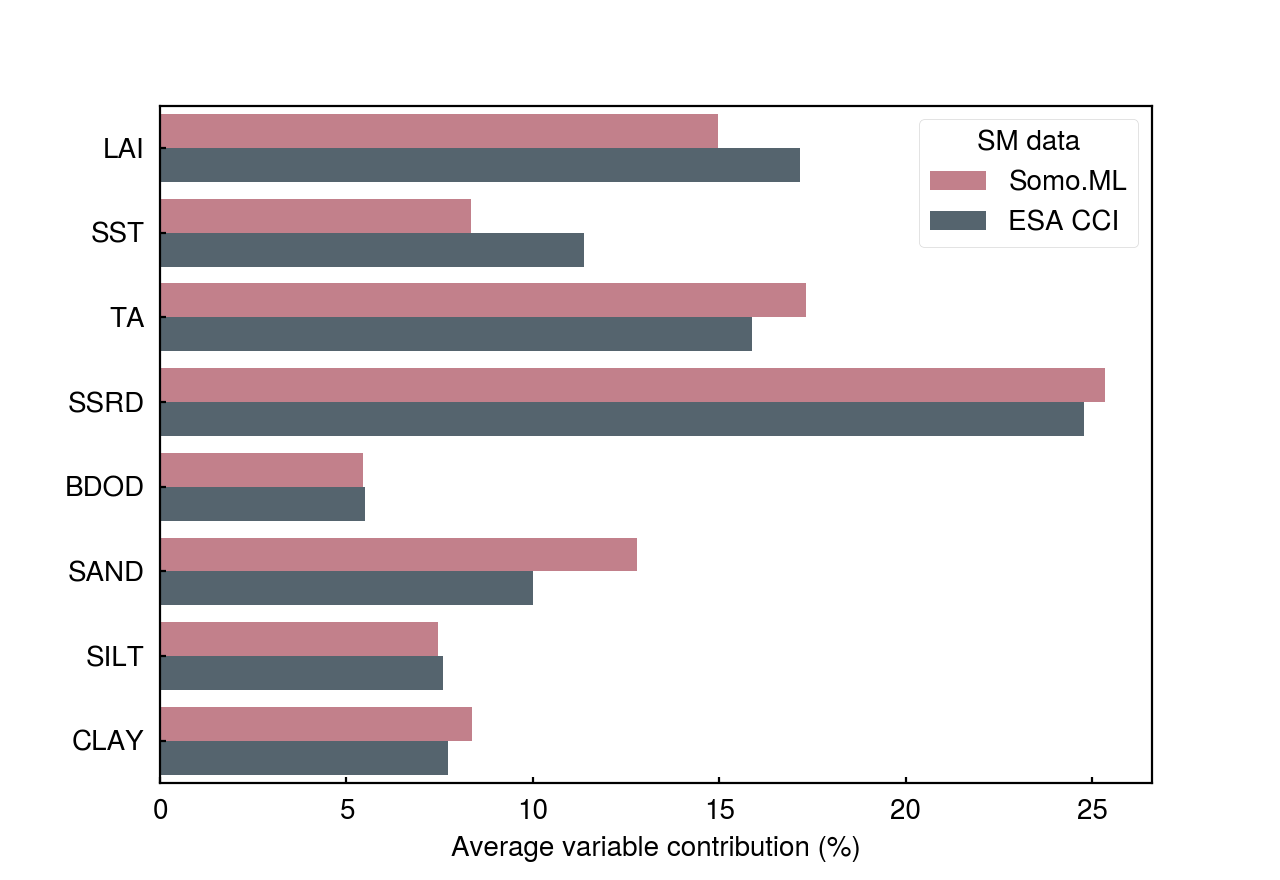

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a single subplot figure using matplotlib
fig, axs = plt.subplots(1,)

# Load feature importance percentages for SoMo and ESA datasets
perc_fv_somo = np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/perc_fv_somo.npy')
perc_fv_esa = np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/perc_fv_esa.npy')

# Assign the single axis to ax5
ax5 = axs

# Define feature labels for the bar plot
labels = ['LAI', 'SST', 'TA', 'SSRD', 'BDOD', 'SAND', 'SILT', 'CLAY']

# Create DataFrames for SoMo and ESA feature importance data
df1 = pd.DataFrame({
    "features": labels,
    "SM data": ['Somo.ML'] * 8,  # SoMo dataset label
    "values": perc_fv_somo * 100  # Convert to percentage
})
df2 = pd.DataFrame({
    "features": labels, 
    "SM data": ['ESA CCI'] * 8,  # ESA dataset label
    "values": perc_fv_esa * 100   # Convert to percentage
})

# Combine both DataFrames
df = pd.concat([df1, df2], axis=0)

# Define color palette for different datasets
palette = {'Somo.ML': 'ugly pink', 'ESA CCI': 'slate'}

# Create horizontal bar plot showing feature importance comparison
sns.barplot(
    y='features',          # Feature names on y-axis
    x='values',            # Importance values on x-axis  
    orient='h',            # Horizontal orientation
    hue='SM data',         # Color by dataset type
    data=df,               # Data source
    ax=ax5,                # Plot axis
    errorbar='sd',         # Show standard deviation as error bars
    palette=palette        # Color scheme
)

# Format plot labels
ax5.set_ylabel("")         # Remove y-axis label
ax5.set_xlabel('Average variable contribution (%)')  # Set x-axis label

# The following lines are commented out but show additional formatting options:
# ax5.spines['right'].set_visible(False)   # Remove right spine
# ax5.spines['top'].set_visible(False)     # Remove top spine  
# ax5.tick_params(axis='x')                # Configure x-axis ticks
# ax5.tick_params(axis='y')                # Configure y-axis ticks
# ax5.legend(title='SM data', title_fontsize=14)  # Customize legend

In [35]:
def plot_monthly_ci(values, ax, color0, color1, label):
    # Create date range from July 2001 to January 2019 with monthly frequency
    date_range = pd.date_range(start='2001-07-01', end='2019-01-01', freq='M')
    
    # Create DataFrame with dates and corresponding values
    df = pd.DataFrame({'date': date_range, 'value': values})
    # Extract month from date for grouping
    df['month'] = df['date'].dt.month
    
    # Calculate monthly statistics: mean, standard deviation, count, and standard error of the mean
    monthly_means = df.groupby('month')['value'].mean()
    monthly_stds = df.groupby('month')['value'].std()
    monthly_counts = df.groupby('month')['value'].count()
    monthly_sems = monthly_stds / np.sqrt(monthly_counts)
    
    # Plot monthly means as a line with markers
    ax.plot(monthly_means.index.to_numpy(), monthly_means.to_numpy(), 
            marker='o', color=color0, label=label)
    
    # Fill between upper and lower 95% confidence intervals (1.96 * SEM)
    ax.fill_between(monthly_means.index, 
                    monthly_means - 1.96 * monthly_sems, 
                    monthly_means + 1.96 * monthly_sems, 
                    color=color1, alpha=0.5, label='_nolegend_')
    return ax

In [36]:
def get_t2_temperal(seeds, model_type):
    # Define model directory paths based on model type
    if model_type == "c1d":
        fold = "/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c1d-2/"
    elif model_type == "c3d":
        fold = "/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/"
    elif model_type == "kc3d":
        fold = "/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/"
    
    reslist = []
    # Iterate through each seed to collect results
    for k in seeds:
        folder_path = fold + str(k)
        f = folder_path + "/"
        # Read R² values from temporal CSV file
        r2_df = pd.read_csv(f + "r2_temperal.csv")
        # Append R² values to results list
        reslist.append(r2_df["r2"])
    
    # Combine all seed results into a single DataFrame
    res_df = pd.concat(reslist, axis=1)
    # Add month column from the original R² DataFrame
    res_df["month"] = r2_df["month"]
    # Calculate mean R² across all seeds for each month
    res_df["mean"] = np.mean(res_df.iloc[:, :len(seeds)], axis=1)
    
    return res_df

In [37]:
# Get temporal R² results for 1D CNN model using specified seeds
c1d_res = get_t2_temperal(seeds=seeds_esa_era_c1d, model_type="c1d")

# Get temporal R² results for 3D CNN model using specified seeds
c3d_res = get_t2_temperal(seeds=seeds_esa_era_c3d, model_type="c3d")

# Get temporal R² results for kernel-based 3D CNN model using specified seeds
kc3d_res = get_t2_temperal(seeds=seeds_esa_era_kc3d, model_type="kc3d")

/tmp/ipykernel_2937938/346625364.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date_range = pd.date_range(start='2001-07-01', end='2019-01-01', freq='M')
/tmp/ipykernel_2937938/346625364.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date_range = pd.date_range(start='2001-07-01', end='2019-01-01', freq='M')
/tmp/ipykernel_2937938/346625364.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date_range = pd.date_range(start='2001-07-01', end='2019-01-01', freq='M')


Text(0, 0.5, 'Monthly avergaed R$^2$')

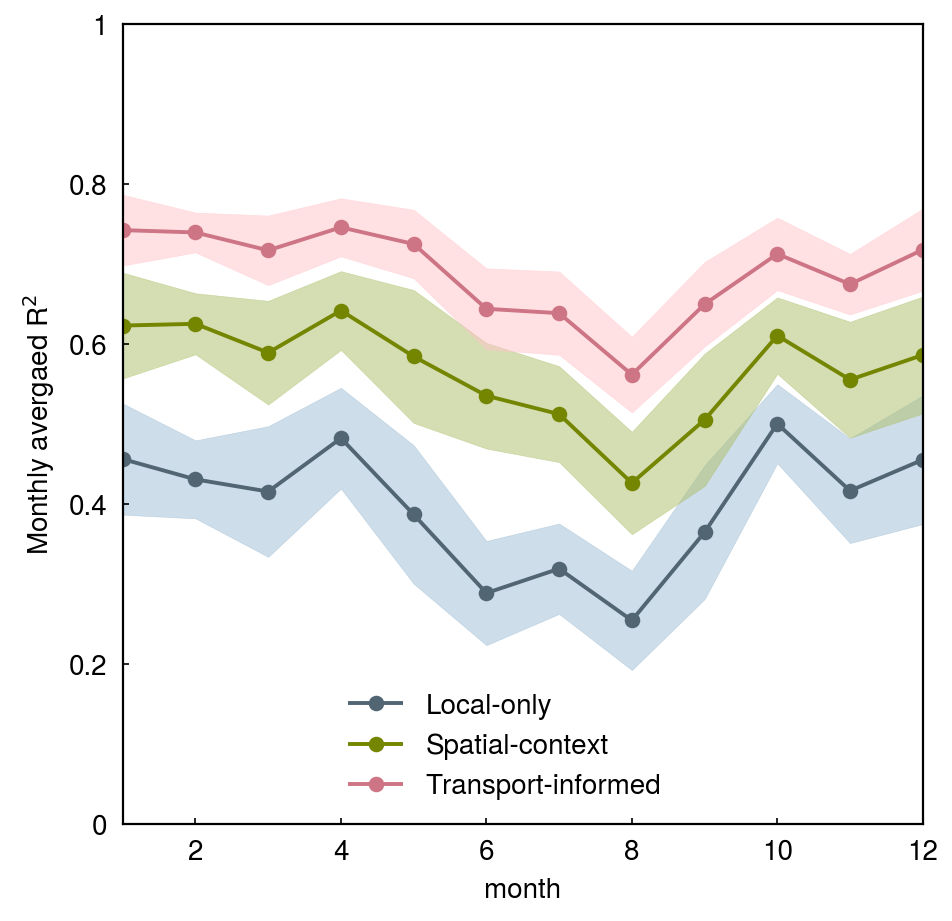

In [41]:
# Define subplot arrangement (single subplot layout)
arrray = [  # the "picture" (0 == nothing, 1 == subplot A, 2 == subplot B, etc.)
    [1, ]
]

# Create figure with specified parameters
fig = uplt.figure(refwidth=4, share=False, span=False, tight=True)

# Create subplots based on arrangement with specific width/height ratios
axs = fig.subplots(arrray, abc=0, width_ratios=[6, ], height_ratios=[ 1])

# Select the first (and only) subplot
ax4 = axs[0]

# Define color schemes for plots and confidence intervals
cplots = ["slate", "swamp green", "ugly pink"]
c_shade_plots = ["light gray blue", "light olive", "light rose"]
# Define legend labels for different models
labels = ["Local-only", "Spatial-context", "Transport-informed"]
# Extract mean R² values from results (c1d_res skips first 6 months)
values = [c1d_res['mean'].values[6:], c3d_res['mean'].values, kc3d_res['mean'].values]

# Plot each model's monthly R² with confidence intervals
for i in range(3):
    axx = plot_monthly_ci(values=values[i], ax=ax4, color0=cplots[i], 
                         color1=c_shade_plots[i], label=labels[i])
    
# Add legend to the plot at specified position
ax4.legend(ncol=1, bbox_to_anchor=(0.25, 0., 0.5, 0.5), 
           bbox_transform=ax4.transAxes, frameon=False)

# Set y-axis limits and label
ax4.set_ylim(0., 1.0)
ax4.set_ylabel("Monthly averaged R$^2$")

# The following lines are commented out but show potential additional customizations:
# ax4.set_xticks([3, 6, 9, 12])  # Set specific x-axis ticks
# ax4.set_xticklabels([ 'Mar.', 'Jun.', 'Sep.', 'Dec.'])  # Custom x-axis labels
# ax7.yaxis.set_label_coords(-0.04, 0)  # Adjust y-label position
# ax4.spines['right'].set_visible(False)  # Hide right spine
# ax4.spines['top'].set_visible(False)  # Hide top spine